# Supplementary QC

## Setup

In [1]:
import os
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import scipy.stats
import seaborn as sns
import statsmodels.stats.proportion
import tqdm

repo = Path.cwd()
if repo.name == "notebooks":
    repo = repo.parent
sys.path.append(str(repo))
from src.IDs import *

figure_dir = repo / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Liberation Sans", "Arial", "sans-serif"]
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

rahbari_df = pl.read_csv(repo / "configs" / "Rahbari.tsv", separator="\t")
sudmant_df = pl.read_csv(repo / "configs" / "Sudmant.tsv", separator="\t")

rahbari_output = Path("/lustre/scratch122/tol/projects/sperm/results/Rahbari_20241121")
sudmant_output = Path("/lustre/scratch122/tol/projects/sperm/results/Sudmant_20241121")


In [2]:
def analysis_paths(config_df, output_path, filename, flow_cell_types=None, sample_ids=None, flow_cells=None, chroms=None):
    df = config_df
    if flow_cell_types is not None:
        df = df.filter(pl.col("flow_cell_type").is_in(flow_cell_types))
    if sample_ids is not None:
        df = df.filter(pl.col("sample_id").is_in(sample_ids))
    if flow_cells is not None:
        df = df.filter(pl.col("flow_cell").is_in(flow_cells))
    if chroms is None:
        chroms = aut_chrom_names
    for sample_set, sample_id, flow_cell in df.select("sample_set", "sample_id", "flow_cell").iter_rows():
        for chrom in chroms:
            yield output_path / "read_analysis" / str(sample_set) / str(sample_id) / str(flow_cell) / chrom / filename

sequel_refinement_files = list(analysis_paths(
    rahbari_df,
    rahbari_output,
    "read_refinement.parquet",
    flow_cell_types=["sequel_ii"],
))
revio_refinement_files = list(analysis_paths(
    rahbari_df,
    rahbari_output,
    "read_refinement.parquet",
    flow_cell_types=["revio_unbinned"],
)) + list(analysis_paths(
    sudmant_df,
    sudmant_output,
    "read_refinement.parquet",
    flow_cell_types=["revio_40"],
))
sequel_snp_files = list(analysis_paths(
    rahbari_df,
    rahbari_output,
    "high_confidence_snps.parquet",
    flow_cell_types=["sequel_ii"],
))
revio_snp_files = list(analysis_paths(
    rahbari_df,
    rahbari_output,
    "high_confidence_snps.parquet",
    flow_cell_types=["revio_unbinned"],
)) + list(analysis_paths(
    sudmant_df,
    sudmant_output,
    "high_confidence_snps.parquet",
    flow_cell_types=["revio_40"],
))

sequel_bq_snp_files = list(analysis_paths(
    rahbari_df,
    rahbari_output,
    "high_confidence_snps.parquet",
    flow_cell_types=["sequel_ii"],
    sample_ids=["PD50521e"],
    flow_cells=["m64222e_220805_105329"],
))
revio_bq_snp_files = list(analysis_paths(
    rahbari_df,
    rahbari_output,
    "high_confidence_snps.parquet",
    flow_cell_types=["revio_unbinned"],
    chroms=["chr1"],
))

path_counts = {
    "Sequel II SNP files": len(sequel_snp_files),
    "Sequel II refinement files": len(sequel_refinement_files),
    "Revio SNP files": len(revio_snp_files),
    "Revio refinement files": len(revio_refinement_files),
    "Sequel II BQ SNP files": len(sequel_bq_snp_files),
    "Revio BQ SNP files": len(revio_bq_snp_files),
}
path_counts


{'Sequel II SNP files': 638,
 'Sequel II refinement files': 638,
 'Revio SNP files': 858,
 'Revio refinement files': 858,
 'Sequel II BQ SNP files': 22,
 'Revio BQ SNP files': 27}

## Read-end trimming

In [3]:
def read_length_coverage(refinement_files, toround=10):
    read_lengths = np.sort(np.concatenate([
        (
            pl.scan_parquet(filename)
            .select("read_name", "read_length1")
            .unique("read_name")
            .collect(streaming=True)
            ["read_length1"].to_numpy()
        )
        for filename in tqdm.tqdm(refinement_files)
        if Path(filename).exists()
    ]))
    xs = np.arange(0, 20000, toround)
    ys = (len(read_lengths) - np.searchsorted(read_lengths, xs)) * toround
    return xs, ys


def read_end_counts(refinement_files, min_bq=8, toround=10):
    start_df = (
        pl.concat([
            (
                pl.scan_parquet(filename)
                .filter(pl.col("read_length1") >= 5000)
                .filter((pl.col("op1") == 8) & (pl.col("op2") == 8) & (pl.col("length") == 1))
                .filter((pl.col("qual_start1") >= min_bq) & (pl.col("qual_start2") >= min_bq))
                .with_columns(rounded_start=pl.col("start") // toround * toround)
                .group_by("rounded_start")
                .len()
                .sort("rounded_start")
            ).collect()
            for filename in tqdm.tqdm(refinement_files)
            if Path(filename).exists()
        ])
        .group_by("rounded_start")
        .sum()
        .sort("rounded_start")
    )
    end_df = (
        pl.concat([
            (
                pl.scan_parquet(filename)
                .filter(pl.col("read_length1") >= 5000)
                .filter((pl.col("op1") == 8) & (pl.col("op2") == 8) & (pl.col("length") == 1))
                .filter((pl.col("qual_start1") >= min_bq) & (pl.col("qual_start2") >= min_bq))
                .with_columns(rounded_end=(pl.col("read_length1") - pl.col("end")) // toround * toround)
                .group_by("rounded_end")
                .len()
                .sort("rounded_end")
            ).collect()
            for filename in tqdm.tqdm(refinement_files)
            if Path(filename).exists()
        ])
        .group_by("rounded_end")
        .sum()
        .sort("rounded_end")
    )
    return start_df, end_df


def read_end_rate(refinement_files, min_bq=8, toround=10):
    start_df, end_df = read_end_counts(refinement_files, min_bq=min_bq, toround=toround)
    xs, ys = read_length_coverage(refinement_files, toround=toround)
    return (
        start_df
        .rename({"len": "start_count"})
        .join(end_df.rename({"len": "end_count", "rounded_end": "rounded_start"}), on="rounded_start")
        .join(pl.DataFrame({"rounded_start": xs, "cov": ys}), on="rounded_start")
        .with_columns(ratio=(pl.col("start_count") + pl.col("end_count")) / (2 * pl.col("cov")))
    )


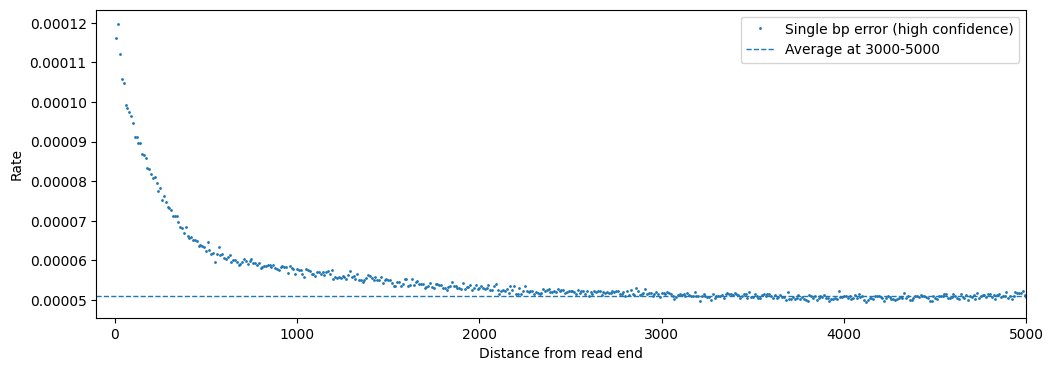

In [4]:
sequel_read_end_df = read_end_rate(sequel_refinement_files[::5], min_bq=8)

plt.figure(figsize=(12, 4));
plt.plot(
    sequel_read_end_df["rounded_start"][1:1000],
    sequel_read_end_df["ratio"][1:1000],
    '.',
    ms=2,
    lw=0.5,
    label="Single bp error (high confidence)",
    color="C0",
);
plt.axhline(sequel_read_end_df["ratio"][300:500].mean(), color="C0", lw=1, ls="--", label="Average at 3000-5000")
plt.xlim(-100, 5000);
plt.legend();
plt.ylabel("Rate");
plt.xlabel("Distance from read end");
plt.savefig(figure_dir / "sequel_read_end_mismatch_calibration.pdf")


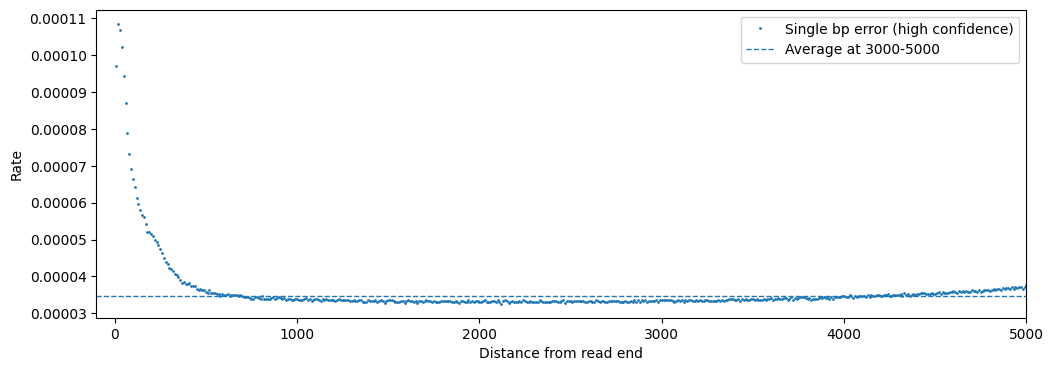

In [5]:
revio_read_end_df = read_end_rate(revio_refinement_files[::5], min_bq=14)

plt.figure(figsize=(12, 4));
plt.plot(
    revio_read_end_df["rounded_start"][1:1000],
    revio_read_end_df["ratio"][1:1000],
    '.',
    ms=2,
    lw=0.5,
    label="Single bp error (high confidence)",
    color="C0",
);
plt.axhline(revio_read_end_df["ratio"][300:500].mean(), color="C0", lw=1, ls="--", label="Average at 3000-5000")
plt.xlim(-100, 5000);
plt.legend();
plt.ylabel("Rate");
plt.xlabel("Distance from read end");
plt.savefig(figure_dir / "revio_read_end_mismatch_calibration.pdf")


## Base quality

In [ ]:
def plot_per_condition(dfs, ax, condition=None):
    if condition is None:
        condition = pl.lit(True)
        
    putative_gc_df_hap_cnt = (
        pl.concat([x.filter(condition)[["qual_rounded", "x_vs_y/y", "x_vs_y/z", "x_vs_y/x"]] for x in dfs])
        .group_by(["qual_rounded"])
        .agg(pl.col("x_vs_y/y").sum(), pl.col("x_vs_y/z").sum(), pl.col("x_vs_y/x").sum())
        .sort("qual_rounded")
    )
    
    import statsmodels.stats.proportion
    A = np.cumsum(putative_gc_df_hap_cnt["x_vs_y/z"][::-1])[::-1]
    B = np.cumsum(putative_gc_df_hap_cnt["x_vs_y/x"][::-1])[::-1]
    p = A / B 
    lo, hi = statsmodels.stats.proportion.proportion_confint(
        A, B,
        method="beta", 
        alpha=0.05
    )

    ax.errorbar(
        x = putative_gc_df_hap_cnt["qual_rounded"],
        y = p,
        yerr = [p-lo, hi-p],
        fmt = '.'
    )

    ax.axhline(0.01, ls="--", lw=0.5, c="black")
    ax.axhline(0.1, ls="--", lw=0.5, c="black")

    ax.set_xlabel("BQ (lower threshold)");
    ax.set_ylabel("Estimated false positive rate");
    ax.set_yscale("log")
    #plt.ylim(0.95,1);


    
    

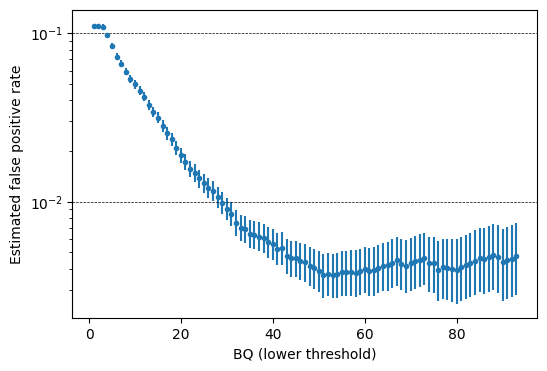

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))

plot_per_condition(dfs, ax, condition=None)

fig.savefig(figure_dir / "sequel_bq_calibration.pdf")

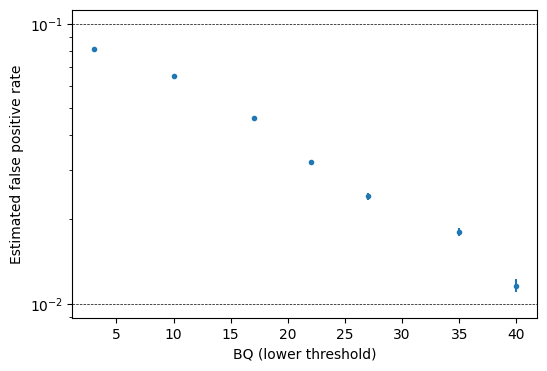

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))

plot_per_condition(dfs, ax, condition=None)

fig.savefig(figure_dir / "revio_bq_calibration.pdf")

## Summary

In [9]:
summary = {
    "Sequel II read-end thresholds bp": {"detection": 1500, "classification": 500},
    "Revio read-end thresholds bp": {"detection": 400, "classification": 200},
    "Sequel II BQ thresholds": {"detection": 60, "classification": 40},
    "Revio BQ thresholds": {"detection": 40, "classification": 30},
}
summary


{'Sequel II read-end thresholds bp': {'detection': 1500,
  'classification': 500},
 'Revio read-end thresholds bp': {'detection': 400, 'classification': 200},
 'Sequel II BQ thresholds': {'detection': 60, 'classification': 40},
 'Revio BQ thresholds': {'detection': 40, 'classification': 30}}